# HW08 Part A :: Convolutional Autoencoder (In-Class Scope)

COSC 6373 -- Adam Nelson-Archer, 2140122

- Install packages if needed:
  - `pip install -U tensorflow matplotlib numpy`
- Dataset structure:
  - `.../flowers/daisy/*.jpg`
  - `.../flowers/dandelion/*.jpg`
  - `.../flowers/rose/*.jpg`
  - `.../flowers/sunflower/*.jpg`
  - `.../flowers/tulip/*.jpg`

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.1


In [2]:
import kagglehub
from pathlib import Path

download_root = Path(kagglehub.dataset_download("alxmamaev/flowers-recognition"))
print("Downloaded to:", download_root)

# In this dataset, images are usually under .../flowers
cfg_data_root = download_root / "flowers"
print("Using dataset folder:", cfg_data_root)

100%|██████████| 225M/225M [00:04<00:00, 47.9MB/s] 

Extracting files...


Downloaded to: C:\Users\Adam\.cache\kagglehub\datasets\alxmamaev\flowers-recognition\versions\2
Using dataset folder: C:\Users\Adam\.cache\kagglehub\datasets\alxmamaev\flowers-recognition\versions\2\flowers


In [3]:
cfg_img_size = (96, 96)
cfg_batch_size = 32
cfg_epochs = 12
cfg_learning_rate = 1e-3
cfg_normal_class = "rose"  # train only on one normal flower class

if not cfg_data_root.exists():
    raise FileNotFoundError(
        f"Dataset path not found: {cfg_data_root}. Set this path to your flowers folder."
    )

print("Data root:", cfg_data_root)
print("Normal class:", cfg_normal_class)

Data root: C:\Users\Adam\.cache\kagglehub\datasets\alxmamaev\flowers-recognition\versions\2\flowers
Normal class: rose


In [4]:
# Use only one normal class for training the autoencoder.
normal_dir = cfg_data_root / cfg_normal_class
if not normal_dir.exists():
    raise FileNotFoundError(f"Normal class folder not found: {normal_dir}")

normal_paths = sorted(list(normal_dir.glob("*.jpg")) + list(normal_dir.glob("*.jpeg")) + list(normal_dir.glob("*.png")))
if len(normal_paths) == 0:
    raise ValueError(f"No images found in {normal_dir}")

rng = np.random.default_rng(SEED)
rng.shuffle(normal_paths)

split_idx = int(0.8 * len(normal_paths))
train_paths = normal_paths[:split_idx]
val_paths = normal_paths[split_idx:]

print("Total normal images:", len(normal_paths))
print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))

Total normal images: 784
Train images: 627
Validation images: 157


In [5]:
def decode_and_resize(path: tf.Tensor, img_size):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape((img_size[0], img_size[1], 3))
    return img


def make_autoencoder_ds(paths, img_size, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices([str(p) for p in paths])
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p: decode_and_resize(p, img_size), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x: (x, x), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_autoencoder_ds(train_paths, cfg_img_size, cfg_batch_size, shuffle=True)
val_ds = make_autoencoder_ds(val_paths, cfg_img_size, cfg_batch_size, shuffle=False)

print(train_ds)
print(val_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None))>


In [6]:
def build_conv_autoencoder(img_size):
    inp = tf.keras.Input(shape=(img_size[0], img_size[1], 3), name="image")

    # Encoder: Conv + MaxPool
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = tf.keras.layers.MaxPooling2D(2, padding="same")(x)
    x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D(2, padding="same")(x)
    x = tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    encoded = tf.keras.layers.MaxPooling2D(2, padding="same", name="encoded")(x)

    # Decoder: Transposed conv upsampling
    x = tf.keras.layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(encoded)
    x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    out = tf.keras.layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)

    return tf.keras.Model(inp, out, name="conv_autoencoder")


autoencoder = build_conv_autoencoder(cfg_img_size)
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cfg_learning_rate),
    loss="mse",
)
autoencoder.summary()

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 24, 24, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 48, 48, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 96, 96, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - loss: 0.0960 - val_loss: 0.0727
Epoch 2/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - loss: 0.0653 - val_loss: 0.0523
Epoch 3/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - loss: 0.0455 - val_loss: 0.0314
Epoch 4/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step - loss: 0.0337 - val_loss: 0.0267
Epoch 5/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 299ms/step - loss: 0.0246 - val_loss: 0.0234
Epoch 6/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 0.0226 - val_loss: 0.0205
Epoch 7/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - loss: 0.0197 - val_loss: 0.0195
Epoch 8/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - loss: 0.0192 - val_loss: 0.0202
Epoch 9/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - loss: 0.0186 - val_loss: 0.0195
Epoch 10/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - loss: 0.0179 - val_loss: 0.0176
Epoch 11/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - loss: 0.0172 - val_loss: 0.0170
Epoch 12/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step

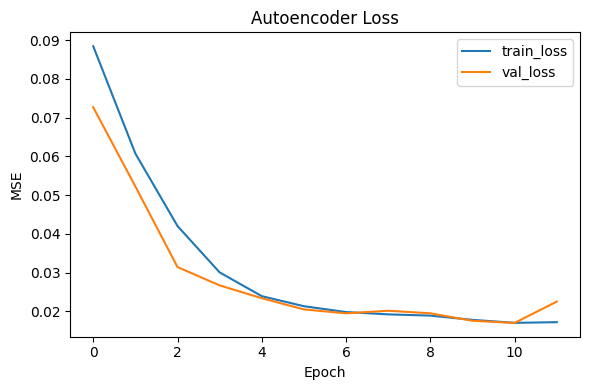

In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
]

history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=cfg_epochs,
    callbacks=callbacks,
    verbose=1,
)

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()

## Acknowledgment

I used a coding assistant (GPT-5.3-Codex) to help scaffold and organize this notebook.